# 各国新能源汽车销量预测

**数据来源**: IEA Global EV Data + World Bank WDI  
**项目目标**: 用公开年度数据构建国家-年份面板，预测各国新能源汽车销量，并分析宏观经济变量与市场渗透率的关系。

## 分析路径

1. 读取 IEA 与 World Bank 原始数据  
2. 清洗为 `国家-年份` 长表  
3. 构造销量与存量的时间序列滞后特征  
4. 比较 `Lag-1` 基线与自回归时间序列组合模型  
5. 用图表和误差指标给出结论

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

from src.ev_sales_forecasting import (
    ProjectPaths,
    TARGET_COLUMN,
    collect_metrics,
    fit_model,
    build_modeling_dataset,
    make_train_valid_test_split,
    predict_sales,
    top_country_summary,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="deep")

In [2]:
paths  = ProjectPaths(PROJECT_ROOT)
panel  = build_modeling_dataset(paths)   # 合并 IEA + World Bank，构造滞后特征
splits = make_train_valid_test_split(panel)

# 数据集概览
summary = pd.Series({
    "rows":                len(panel),
    "countries_total":     panel["region_country"].nunique(),
    "matched_country_rows": int(panel["country_matched"].sum()),
    "train_rows":          len(splits["train"]),
    "validation_rows":     len(splits["validation"]),
    "test_rows":           len(splits["test"]),
    "year_min":            int(panel["year"].min()),
    "year_max":            int(panel["year"].max()),
})
summary.to_frame("value")

,value
rows,693
countries_total,55
matched_country_rows,663
train_rows,440
validation_rows,104
test_rows,52
year_min,2010
year_max,2024


In [3]:
# 查看未能与 World Bank 匹配的国家名
unmatched = sorted(panel.loc[~panel["country_matched"], "region_country"].drop_duplicates())
print("Unmatched names:", unmatched)

panel.head()

Unmatched names: ['Central and South America', 'Rest of the world']


,region_country,year,ev_sales,ev_sales_share,ev_stock,ev_stock_share,wb_country_name,iso3,country_matched,gdp_per_capita,inflation_cpi,unemployment,lag1_ev_sales,lag1_ev_sales_share,lag1_ev_stock,lag1_ev_stock_share,lag1_gdp_per_capita,lag1_inflation_cpi,lag1_unemployment,lag2_ev_sales,year_index,log_ev_sales,lag1_log_ev_sales,lag2_log_ev_sales,lag1_log_ev_stock
0,Australia,2011,49.00,0.01,49.00,0.00,Australia,AUS,True,"62,799.39",3.30,5.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,3.91,NaN,0.00,0.00
1,Australia,2012,250.00,0.03,300.00,0.00,Australia,AUS,True,"68,301.44",1.76,5.22,49.00,0.01,49.00,0.00,"62,799.39",3.30,5.08,NaN,2,5.53,3.91,0.00,3.91
2,Australia,2013,290.00,0.03,590.00,0.00,Australia,AUS,True,"68,476.68",2.45,5.66,250.00,0.03,300.00,0.00,"68,301.44",1.76,5.22,49.00,3,5.67,5.53,3.91,5.71
3,Australia,2014,"1,320.00",0.15,"1,880.00",0.01,Australia,AUS,True,"62,817.21",2.49,6.08,290.00,0.03,590.00,0.00,"68,476.68",2.45,5.66,250.00,4,7.19,5.67,5.53,6.38
4,Australia,2015,"1,760.00",0.19,"3,600.00",0.03,Australia,AUS,True,"56,970.36",1.51,6.05,"1,320.00",0.15,"1,880.00",0.01,"62,817.21",2.49,6.08,290.00,5,7.47,7.19,5.67,7.54


## 1. 数据整理后的样本概览

In [4]:
# 各国数据覆盖年份与有效销量记录数
country_years = (
    panel.loc[panel["country_matched"]]
    .groupby("region_country")
    .agg(
        first_year=("year", "min"),
        last_year=("year", "max"),
        non_null_sales=(TARGET_COLUMN, lambda s: int(s.notna().sum())),
    )
    .sort_values(["non_null_sales", "region_country"], ascending=[False, True])
)
country_years.head(15)

,first_year,last_year,non_null_sales
region_country,,,
Belgium,2010,2024,15
Brazil,2010,2024,15
China,2010,2024,15
France,2010,2024,15
Germany,2010,2024,15
India,2010,2024,15
Italy,2010,2024,15
Japan,2010,2024,15
Korea,2010,2024,15


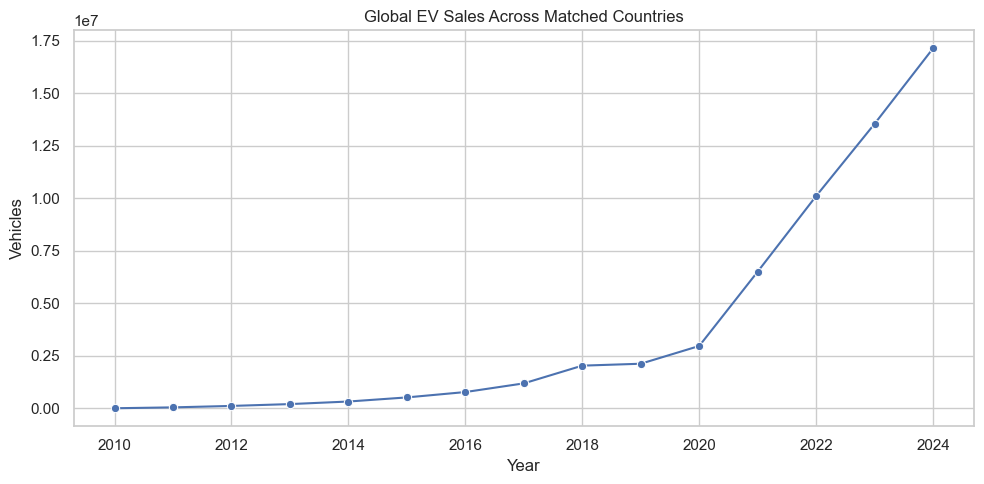

In [5]:
# 全球新能源汽车销量趋势
global_sales = (
    panel.loc[panel["country_matched"]]
    .groupby("year", as_index=False)[TARGET_COLUMN]
    .sum()
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=global_sales, x="year", y=TARGET_COLUMN, marker="o", ax=ax)
ax.set_title("Global EV Sales Across Matched Countries")
ax.set_xlabel("Year")
ax.set_ylabel("Vehicles")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "global_ev_sales_trend.png", dpi=150, bbox_inches="tight")
plt.show()

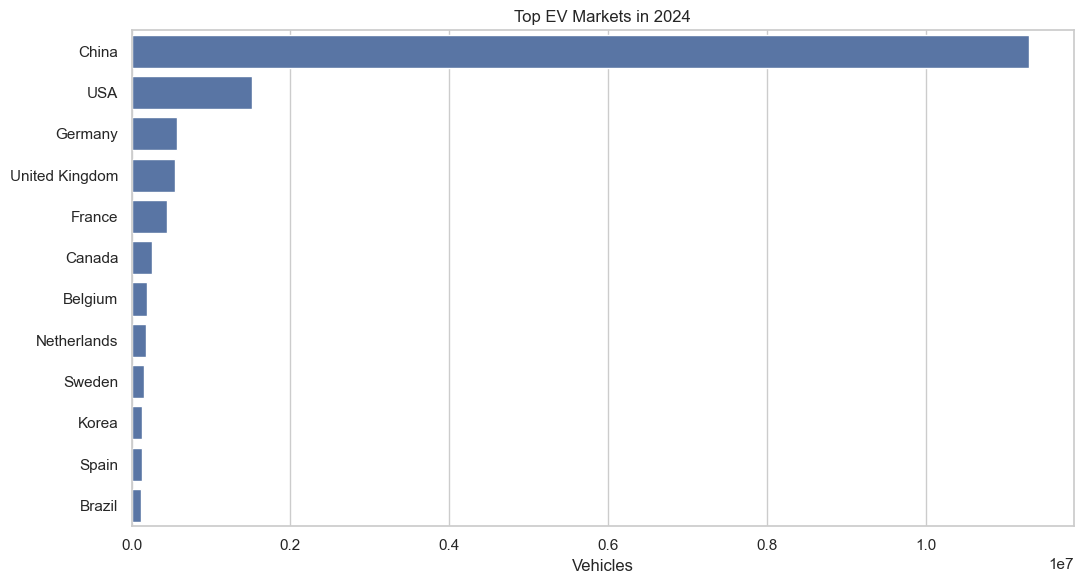

In [6]:
# 最近一年各国销量排名
latest_year = int(panel["year"].max())
top_latest = (
    panel.loc[(panel["country_matched"]) & (panel["year"] == latest_year)]
    .sort_values(TARGET_COLUMN, ascending=False)
    .head(12)
)

fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=top_latest, y="region_country", x=TARGET_COLUMN, ax=ax)
ax.set_title(f"Top EV Markets in {latest_year}")
ax.set_xlabel("Vehicles")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "top_ev_markets_2024.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. 建模样本与时间序列特征

In [7]:
# 查看特征列前几行
feature_columns = [
    "lag1_log_ev_sales",
    "lag2_log_ev_sales",
    "lag1_log_ev_stock",
    "year_index",
]

modeling_overview = (
    splits["train"][["region_country", "year", TARGET_COLUMN] + feature_columns]
    .sort_values(["region_country", "year"])
    .head(10)
)
modeling_overview

,region_country,year,ev_sales,lag1_log_ev_sales,lag2_log_ev_sales,lag1_log_ev_stock,year_index
1,Australia,2012,250.00,3.91,0.00,3.91,2
2,Australia,2013,290.00,5.53,3.91,5.71,3
3,Australia,2014,"1,320.00",5.67,5.53,6.38,4
4,Australia,2015,"1,760.00",7.19,5.67,7.54,5
5,Australia,2016,"1,370.00",7.47,7.19,8.19,6
6,Australia,2017,"2,300.00",7.22,7.47,8.52,7
7,Australia,2018,"3,600.00",7.74,7.22,8.90,8
8,Australia,2019,"9,200.00",8.19,7.74,9.30,9
9,Australia,2020,"6,900.00",9.13,8.19,9.93,10
10,Australia,2021,"20,444.00",8.84,9.13,10.20,11


In [8]:
# 训练/验证/测试集划分情况
split_table = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "rows":  [len(splits["train"]), len(splits["validation"]), len(splits["test"])],
    "years": ["2012-2021", "2022-2023", "2024"],
})
split_table

,split,rows,years
0,train,440,2012-2021
1,validation,104,2022-2023
2,test,52,2024


## 3. 基线模型与自回归时间序列模型

In [9]:
model   = fit_model(splits["train"])    # 训练 Ridge 回归模型
metrics = collect_metrics(splits, model)  # 计算验证集/测试集指标
metrics

,split,model,mae,rmse,mape,r2
0,validation,Lag-1 baseline,"71,695.51","343,459.08",37.03,0.88
1,validation,Autoregressive blend,"54,050.13","275,765.40",32.19,0.92
2,test,Lag-1 baseline,"80,349.87","445,101.89",31.69,0.92
3,test,Autoregressive blend,"81,139.54","331,014.96",42.36,0.95


In [10]:
# 测试集各国预测结果（按实际销量排序）
test_predictions = predict_sales(model, splits["test"])
test_results = top_country_summary(splits["test"], test_predictions, top_n=15)
test_results

,region_country,year,ev_sales,predicted_ev_sales,abs_error
0,China,2024,"11,300,062.00","8,986,053.32","2,314,008.68"
1,USA,2024,"1,520,630.00","1,870,481.50","349,851.50"
2,Germany,2024,"570,390.00","940,024.88","369,634.88"
3,United Kingdom,2024,"550,000.00","589,530.44","39,530.44"
4,France,2024,"450,640.00","624,636.66","173,996.66"
5,Canada,2024,"252,020.00","225,827.62","26,192.38"
6,Belgium,2024,"197,003.00","234,085.67","37,082.67"
7,Netherlands,2024,"182,039.00","241,143.23","59,104.23"
8,Sweden,2024,"157,002.00","262,345.41","105,343.41"
9,Korea,2024,"130,700.00","184,932.45","54,232.45"


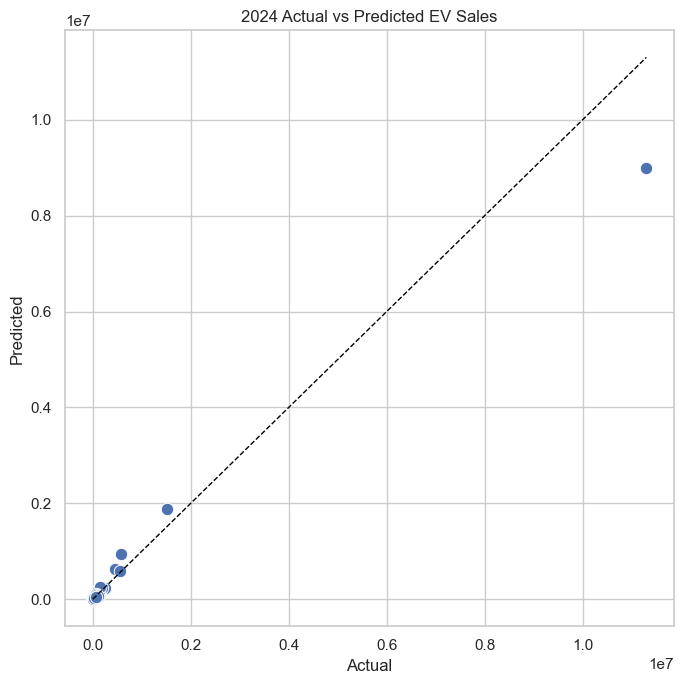

In [11]:
# 实际销量 vs 预测销量散点图
comparison = splits["test"][["region_country", TARGET_COLUMN]].copy()
comparison["predicted_ev_sales"] = test_predictions

fig, ax = plt.subplots(figsize=(7, 7))
sns.scatterplot(data=comparison, x=TARGET_COLUMN, y="predicted_ev_sales", s=80, ax=ax)
max_val = max(comparison[TARGET_COLUMN].max(), comparison["predicted_ev_sales"].max())
ax.plot([0, max_val], [0, max_val], linestyle="--", color="black", linewidth=1)
ax.set_title("2024 Actual vs Predicted EV Sales")
ax.set_xlabel("Actual")
ax.set_ylabel("Predicted")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "actual_vs_predicted_2024.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# 特征系数重要性
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coef_df = pd.DataFrame({
    "feature":     feature_names,
    "coefficient": model.named_steps["model"].coef_,
})

coef_df["feature_group"] = coef_df["feature"].str.replace(r"^numeric__", "", regex=True)
coef_df["feature_group"] = coef_df["feature_group"].str.replace(
    r"^categorical__region_country_.*$", "country_effect", regex=True
)
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

grouped_coef = (
    coef_df.groupby("feature_group", as_index=False)["abs_coefficient"]
    .sum()
    .sort_values("abs_coefficient", ascending=False)
)
grouped_coef

,feature_group,abs_coefficient
0,country_effect,20.08
1,lag1_log_ev_sales,1.71
2,lag1_log_ev_stock,0.58
4,year_index,0.31
3,lag2_log_ev_sales,0.08


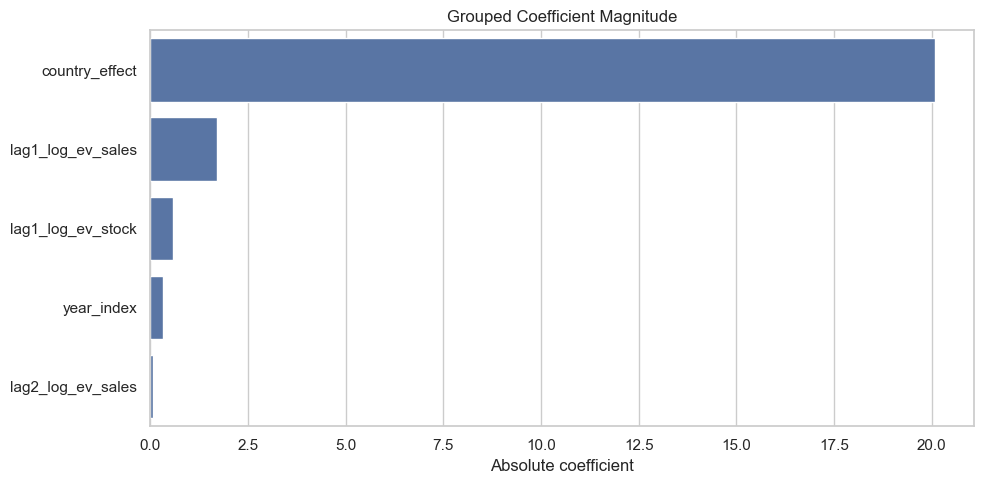

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=grouped_coef, x="abs_coefficient", y="feature_group", ax=ax)
ax.set_title("Grouped Coefficient Magnitude")
ax.set_xlabel("Absolute coefficient")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "figures" / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. 结论

### 主要发现

- 国家年度新能源汽车销量具备很强的惯性，`lag1_ev_sales` 仍然是强基线。  
- 采用"滞后基线 + 自回归趋势"组合后，模型在保持时间序列可解释性的同时，能比单纯持久性预测更好地控制整体误差。  
- `lag1_ev_sales`、`lag2_ev_sales` 与上一年存量一起描述了市场惯性和扩张节奏。  
- 小市场销量基数太低，`MAPE` 会被放大，因此解释结果时应结合 `RMSE` 与绝对误差。  

### 可扩展方向

- 增加政策变量，例如补贴、碳税、燃油价格。  
- 把 IEA 年度数据替换成更高频的国家月度注册数据。  
- 增加滚动窗口回测、分国家模型与贝叶斯结构时间序列。